# Air Quality Forecasting with RNN/LSTM

This notebook implements Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) models to forecast PM2.5 air pollution concentrations in Beijing.

## Table of Contents
1. [Import Libraries](#import)
2. [Data Loading](#loading)
3. [Data Exploration](#exploration)
4. [Data Preprocessing](#preprocessing)
5. [Sequence Creation for Time Series](#sequences)
6. [Model Architecture](#architecture)
7. [Training and Experiments](#training)
8. [Results Analysis](#results)
9. [Predictions Generation](#predictions)

## 1. Import Libraries <a id="import"></a>

In [47]:
# Standard library imports
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math

# Machine Learning libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU, SimpleRNN, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Bidirectional
from sklearn.metrics import mean_squared_error



# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
TensorFlow version: 2.20.0
NumPy version: 2.3.0
Pandas version: 2.3.0


## 2. Data Loading <a id="loading"></a>

We load the training and test datasets. The training data contains historical air quality and weather features along with PM2.5 target values. The test data contains only features, and we need to predict PM2.5 values.

In [48]:
# Define paths - adjust these paths based on where you've saved the data files
DATA_DIR = '../data'  # Path to data directory relative to notebook location

# Load datasets
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission .csv'))

print("="*60)
print("Dataset Loading Summary")
print("="*60)
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Sample submission shape: {sample_submission.shape}")
print("\nTraining data columns:")
print(train_df.columns.tolist())
print("\nTraining data first few rows:")
train_df.head()

Dataset Loading Summary
Training data shape: (30676, 12)
Test data shape: (13148, 11)
Sample submission shape: (13148, 2)

Training data columns:
['No', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'datetime', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'pm2.5']

Training data first few rows:


,No,DEWP,TEMP,PRES,Iws,Is,Ir,datetime,cbwd_NW,cbwd_SE,cbwd_cv,pm2.5
0,1,-1.580878,-1.922250,0.443328,-0.441894,-0.069353,-0.137667,2010-01-01 00:00:00,1.448138,-0.732019,-0.522096,NaN
1,2,-1.580878,-2.004228,0.345943,-0.379306,-0.069353,-0.137667,2010-01-01 01:00:00,1.448138,-0.732019,-0.522096,NaN
2,3,-1.580878,-1.922250,0.248559,-0.343514,-0.069353,-0.137667,2010-01-01 02:00:00,1.448138,-0.732019,-0.522096,NaN
3,4,-1.580878,-2.168183,0.248559,-0.280926,-0.069353,-0.137667,2010-01-01 03:00:00,1.448138,-0.732019,-0.522096,NaN
4,5,-1.511594,-2.004228,0.151174,-0.218339,-0.069353,-0.137667,2010-01-01 04:00:00,1.448138,-0.732019,-0.522096,NaN


#  Time Feature Engineering Function

This function enriches a dataset with **lagged values, rolling statistics, and temporal features** to improve time series modeling.

### Function: `add_time_features(df, target_col=None, lags=[1,7,30], rolling_windows=[7,14,30])`

### Steps:
1. **Lag Features (if target column exists)**
   - Adds lagged versions of the target variable:
     - `lag_1`, `lag_7`, `lag_30`
   - Captures short-, medium-, and long-term dependencies.

2. **Rolling Window Features**
   - Adds rolling statistics of the target variable:
     - Rolling mean (`roll_mean_7`, `roll_mean_14`, `roll_mean_30`)
     - Rolling standard deviation (`roll_std_7`, `roll_std_14`, `roll_std_30`)
   - Helps capture local trends and volatility.

3. **Datetime Features (always added if `datetime` column exists)**
   - Converts `datetime` column to proper `datetime` type.
   - Extracts cyclical time features:
     - **Hour cycle (24h):** `hour_sin`, `hour_cos`
     - **Month cycle (12m):** `month_sin`, `month_cos`
   - Drops linear `hour` and `month` columns after encoding.
   - Adds additional time-based features:
     - `dayofweek`
     - `year`

4. **Return**
   - Returns a copy of the DataFrame with added time-based features.

### Purpose:
- Provides lagged and rolling features for capturing temporal dependencies.
- Encodes cyclical time features (hour, month) using sine/cosine to preserve periodicity.
- Adds calendar-based features (day of week, year) for seasonality and trend detection.

In [49]:
def add_time_features(df, target_col=None, lags=[1,7,30], rolling_windows=[7,14,30]):
    df = df.copy()

    # Only add lag/rolling if target_col exists
    if target_col and target_col in df.columns:
        for lag in lags:
            df[f'lag_{lag}'] = df[target_col].shift(lag)

        for window in rolling_windows:
            df[f'roll_mean_{window}'] = df[target_col].shift(1).rolling(window).mean()
            df[f'roll_std_{window}'] = df[target_col].shift(1).rolling(window).std()

    # Always add datetime features
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df['hour'] = df['datetime'].dt.hour
        df['month'] = df['datetime'].dt.month
        
        # --- WE ADD CIRCULAR FEATURES HERE ---
        # Hour cycle (24 hours)
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        
        # Month cycle (12 months)
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        

        # We DROP the linear columns now that we have the sin/cos versions
        df.drop(['hour', 'month'], axis=1, inplace=True)
        
        # We also add these useful time features
        df['dayofweek'] = df['datetime'].dt.dayofweek
        df['year'] = df['datetime'].dt.year
       

    return df

In [50]:
# Train set: add lag/rolling features using pm2.5
train_df = add_time_features(train_df, target_col='pm2.5')

# Test set: only add datetime-based features (no pm2.5 column available)
test_df = add_time_features(test_df, target_col=None)

## 3. Data Exploration <a id="exploration"></a>

Data exploration is crucial for understanding the dataset characteristics, identifying patterns, detecting anomalies, and informing preprocessing decisions. We examine:
- **Dataset structure**: Shape, data types, and column information
- **Missing values**: Critical for time series as gaps can affect model performance
- **Statistical summary**: Understanding data distributions helps in feature scaling
- **Temporal patterns**: Visualizing trends and seasonality in PM2.5 over time
- **Feature distributions**: Histograms reveal data spread and potential outliers
- **Correlations**: Understanding relationships between features and target

In [51]:
# Basic information about the dataset
print("="*60)
print("Dataset Information")
print("="*60)
print("\nTraining Data Info:")
print(train_df.info())

print("\n" + "="*60)
print("Statistical Summary")
print("="*60)
print(train_df.describe())

Dataset Information

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30676 entries, 0 to 30675
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   No            30676 non-null  int64         
 1   DEWP          30676 non-null  float64       
 2   TEMP          30676 non-null  float64       
 3   PRES          30676 non-null  float64       
 4   Iws           30676 non-null  float64       
 5   Is            30676 non-null  float64       
 6   Ir            30676 non-null  float64       
 7   datetime      30676 non-null  datetime64[ns]
 8   cbwd_NW       30676 non-null  float64       
 9   cbwd_SE       30676 non-null  float64       
 10  cbwd_cv       30676 non-null  float64       
 11  pm2.5         28755 non-null  float64       
 12  lag_1         28754 non-null  float64       
 13  lag_7         28748 non-null  float64       
 14  lag_30        28725 non-null  float64       


#  Missing Values Analysis

This cell checks for missing values in both **training** and **test** datasets and visualizes them if present.

### Purpose:
- Detect missing values in time series data, which may indicate sensor failures or data collection issues.
- Ensure proper handling to maintain temporal continuity in modeling.

### Steps:
1. **Compute Missing Values**
   - Calculates missing values per column in `train_df` and `test_df`.
   - Prints columns with missing values and total counts.

2. **Visualization (if missing values exist)**
   - Creates a 1×2 subplot:
     - **Training Data**: Bar chart of missing values per column (coral).
     - **Test Data**: Bar chart of missing values per column (light blue).
   - Adds titles, labels, and rotated x-axis ticks for readability.

3. **No Missing Values Case**
   - Prints a message confirming that no missing values were found.

### Outcome:
Provides a clear overview of missing data patterns in both training and test sets, guiding decisions on imputation, interpolation, or exclusion strategies.

Missing Values Analysis

Training data missing values:
pm2.5           1921
lag_1           1922
lag_7           1928
lag_30          1951
roll_mean_7     2793
roll_std_7      2793
roll_mean_14    3721
roll_std_14     3721
roll_mean_30    5511
roll_std_30     5511
dtype: int64

Total missing values in training: 31772

Test data missing values:
Series([], dtype: int64)

Total missing values in test: 0


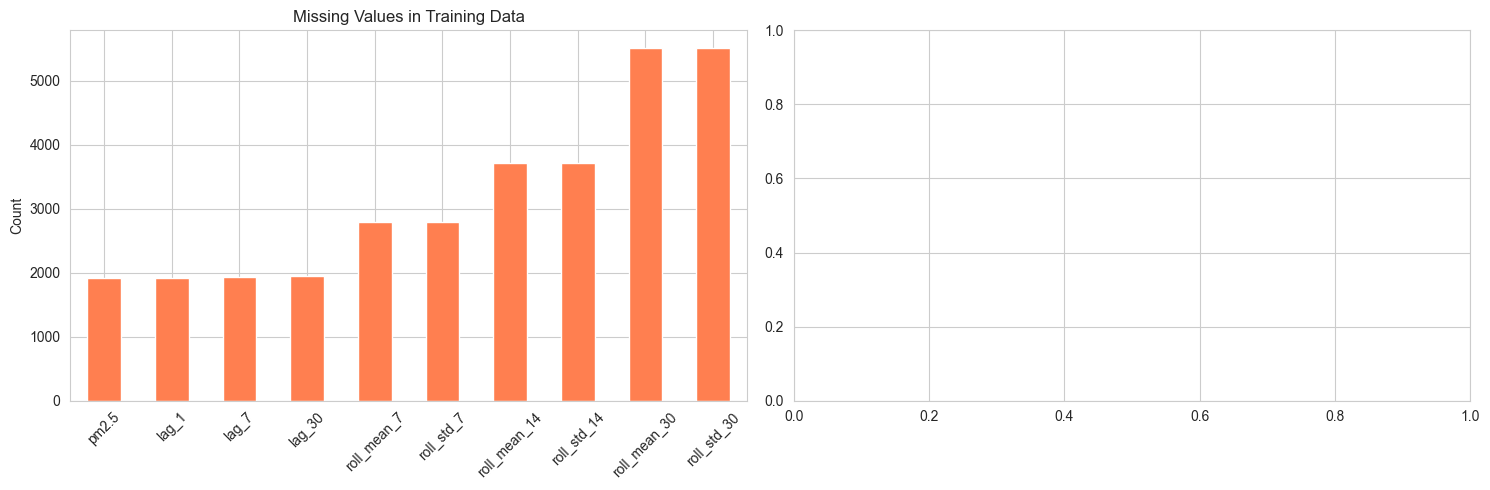

In [52]:
# Check for missing values
# Missing values in time series data can indicate sensor failures or data collection issues
# We need to handle these carefully to maintain temporal continuity
print("="*60)
print("Missing Values Analysis")
print("="*60)
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()

print("\nTraining data missing values:")
print(missing_train[missing_train > 0])
print(f"\nTotal missing values in training: {missing_train.sum()}")

print("\nTest data missing values:")
print(missing_test[missing_test > 0])
print(f"\nTotal missing values in test: {missing_test.sum()}")

# Visualize missing values if any exist
if missing_train.sum() > 0 or missing_test.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Training data missing values
    if missing_train.sum() > 0:
        missing_train[missing_train > 0].plot(kind='bar', ax=axes[0], color='coral')
        axes[0].set_title('Missing Values in Training Data')
        axes[0].set_ylabel('Count')
        axes[0].tick_params(axis='x', rotation=45)
    
    # Test data missing values
    if missing_test.sum() > 0:
        missing_test[missing_test > 0].plot(kind='bar', ax=axes[1], color='lightblue')
        axes[1].set_title('Missing Values in Test Data')
        axes[1].set_ylabel('Count')
        axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values found in the dataset!")

#  Target Column Identification (PM2.5)

This cell identifies the target variable (PM2.5) and separates it from the feature set.

### Steps:
1. **Search for Target Column**
   - Iterates through `train_df.columns`.
   - Looks for column names containing `"PM2.5"` or `"PM"` (case-insensitive).

2. **Fallbacks if Not Found**
   - If no PM2.5 column is detected:
     - Prints a warning and checks `sample_submission` format.
     - Identifies target as any column present in `train_df` but missing in `test_df`.
     - If still not found, assumes the **last column** in `train_df` is the target.

3. **Store Target Variable**
   - Saves target values into `y_train`.
   - Ensures fallback to last column if `target_col` is not identified.

4. **Define Feature Columns**
   - Sets `feature_cols` as all columns except the target.
   - Prints:
     - Number of features.
     - First 10 feature column names for inspection.

### Purpose:
Ensures the correct identification of the **PM2.5 target column** for supervised learning, while robustly handling cases where the column name or format differs.

In [ ]:
target_col = None
for col in train_df.columns:
    if 'PM2.5' in col.upper() or 'PM' in col.upper():
        target_col = col
        break

if target_col is None:
    # If no PM2.5 column found, assume last column is target or check sample submission
    print("Warning: PM2.5 column not found. Checking sample submission format...")
    print("Sample submission columns:", sample_submission.columns.tolist())
    # Common convention: target might be named 'target', 'PM2.5', or be the last column
    # We'll identify it based on what's not in test data
    target_col = [col for col in train_df.columns if col not in test_df.columns]
    if target_col:
        target_col = target_col[0]
        print(f"Target column identified as: {target_col}")
    else:
        # Fallback: assume last column is target
        target_col = train_df.columns[-1]
        print(f"Using last column as target: {target_col}")
else:
    print(f"Target column identified: {target_col}")

# Store target variable separately
y_train = train_df[target_col].values if target_col else train_df.iloc[:, -1].values

# Feature columns (all except target)
feature_cols = [col for col in train_df.columns if col != target_col]
print(f"\nNumber of features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}...")  # Show first 10

Target column identified: pm2.5

Number of features: 26
Feature columns: ['No', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'datetime', 'cbwd_NW', 'cbwd_SE']...


#  PM2.5 Target Distribution Analysis

This cell visualizes and summarizes the distribution of the target variable **PM2.5**.

### Purpose:
- Detect **data skewness** (may suggest log transformation).
- Identify **outliers** (may require clipping or robust scaling).
- Understand the **range of values** (informs scaling decisions).
- Check **normality assumptions** for modeling.

### Visualizations:
1. **Histogram**
   - Shows overall distribution shape.
   - Highlights mean (red dashed line) and median (green dashed line).
   - Useful for detecting skewness and spread.

2. **Box Plot**
   - Displays quartiles and outliers.
   - Helps identify extreme values that may distort training.

3. **Time Series Plot**
   - Plots the first 1000 samples of PM2.5 values.
   - Useful for spotting temporal trends, seasonality, or anomalies.

4. **Q-Q Plot**
   - Compares PM2.5 distribution against a normal distribution.
   - Assesses normality and tail behavior.

### Statistics Printed:
- **Mean**
- **Median**
- **Standard Deviation**
- **Minimum / Maximum**
- **Skewness** (positive = right-skewed)
- **Kurtosis** (positive = heavy-tailed)

### Outcome:
Provides a comprehensive view of PM2.5 distribution, guiding preprocessing decisions such as transformations, scaling, and outlier handling.

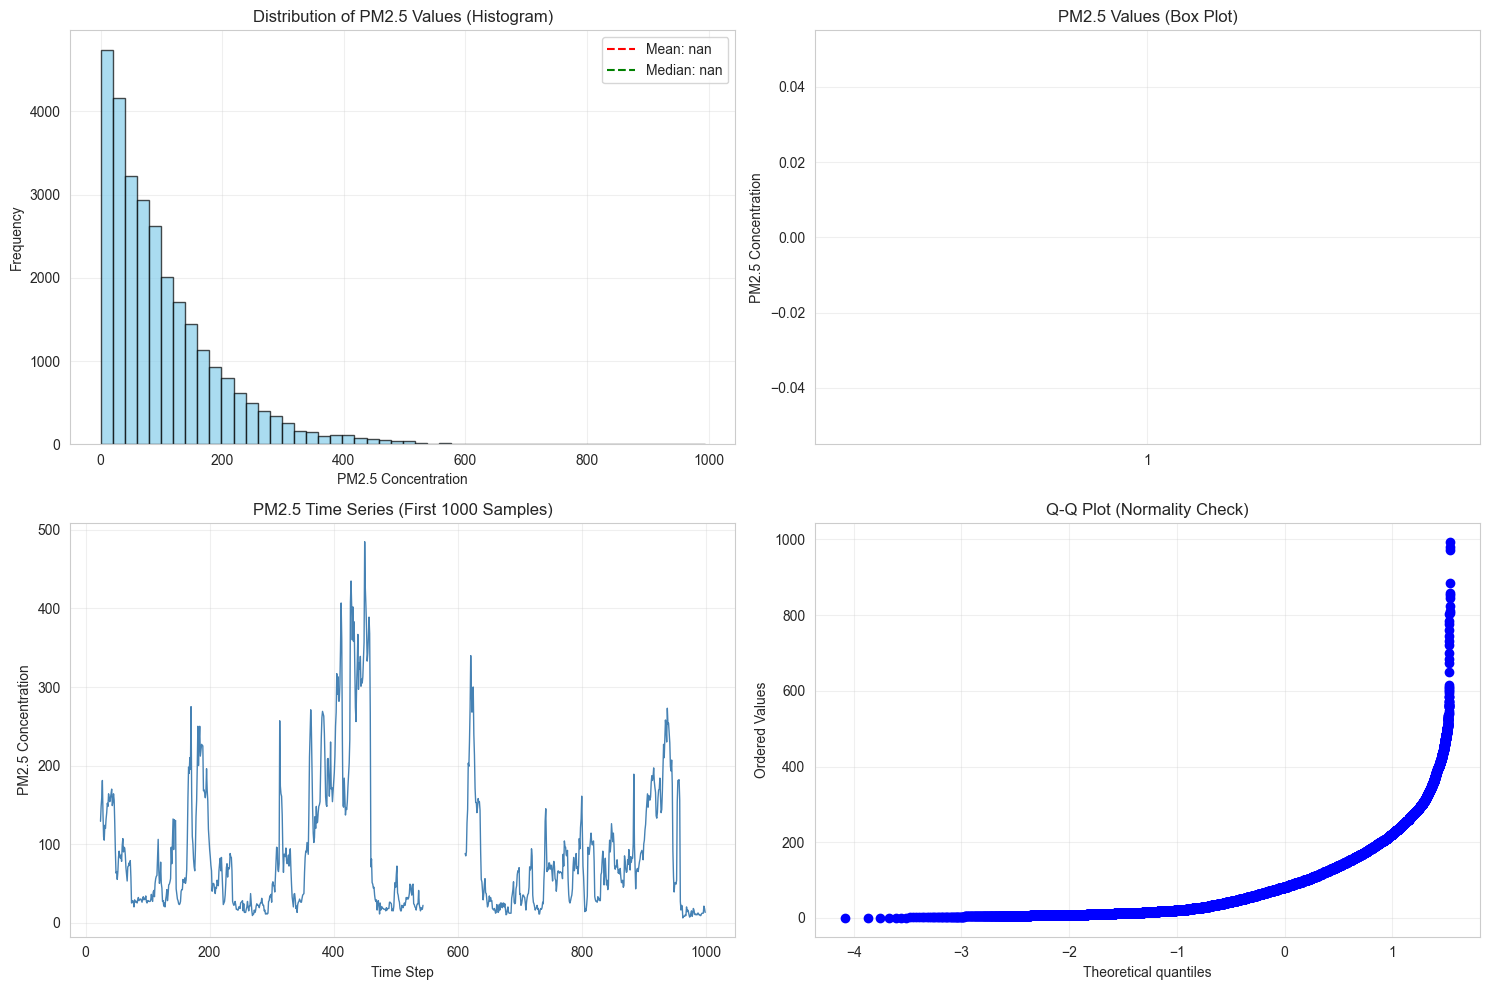

PM2.5 Target Statistics
Mean: nan
Median: nan
Std: nan
Min: nan
Max: nan
Skewness: nan
Kurtosis: nan


In [54]:
# Visualize PM2.5 distribution
# Understanding the target distribution helps identify:
# - Data skewness (may require log transformation)
# - Outliers (may need clipping or robust scaling)
# - Range of values (informs scaling decisions)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram - shows distribution shape
axes[0, 0].hist(y_train, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of PM2.5 Values (Histogram)')
axes[0, 0].set_xlabel('PM2.5 Concentration')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(np.mean(y_train), color='red', linestyle='--', label=f'Mean: {np.mean(y_train):.2f}')
axes[0, 0].axvline(np.median(y_train), color='green', linestyle='--', label=f'Median: {np.median(y_train):.2f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot - shows quartiles and outliers
axes[0, 1].boxplot(y_train, vert=True)
axes[0, 1].set_title('PM2.5 Values (Box Plot)')
axes[0, 1].set_ylabel('PM2.5 Concentration')
axes[0, 1].grid(True, alpha=0.3)

# Time series plot (if temporal column exists)
# This visualization helps identify trends, seasonality, and patterns over time
if len(y_train) > 0:
    axes[1, 0].plot(y_train[:1000], color='steelblue', linewidth=1)  # Plot first 1000 points for clarity
    axes[1, 0].set_title('PM2.5 Time Series (First 1000 Samples)')
    axes[1, 0].set_xlabel('Time Step')
    axes[1, 0].set_ylabel('PM2.5 Concentration')
    axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot - checks for normality
from scipy import stats
stats.probplot(y_train, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*60)
print("PM2.5 Target Statistics")
print("="*60)
print(f"Mean: {np.mean(y_train):.4f}")
print(f"Median: {np.median(y_train):.4f}")
print(f"Std: {np.std(y_train):.4f}")
print(f"Min: {np.min(y_train):.4f}")
print(f"Max: {np.max(y_train):.4f}")
print(f"Skewness: {stats.skew(y_train):.4f}")  # Positive = right-skewed
print(f"Kurtosis: {stats.kurtosis(y_train):.4f}")  # Positive = heavy-tailed

#  Feature Correlation Analysis

This cell analyzes correlations between numeric features and the target variable **PM2.5**.

### Purpose:
- Identify features strongly related to PM2.5 (important predictors).
- Detect multicollinearity (redundant features).
- Inform feature selection and engineering decisions.

### Steps:
1. **Select Numeric Features**
   - Extracts numeric-only columns from `train_df[feature_cols]`.

2. **Correlation Calculation**
   - Computes correlation of each numeric feature with the target (`y_train`).
   - Sorts correlations in descending order.

3. **Visualization**
   - Plots top 20 correlated features (or fewer if less available) as a horizontal bar chart.
   - Title: *Top Feature Correlations with PM2.5*.
   - X-axis: correlation coefficient.

4. **Output**
   - Prints the top 10 most correlated features with PM2.5.
   - Warns if no numeric features are found.

### Outcome:
Provides insights into which features are most predictive of PM2.5 levels and highlights potential redundancy among features.

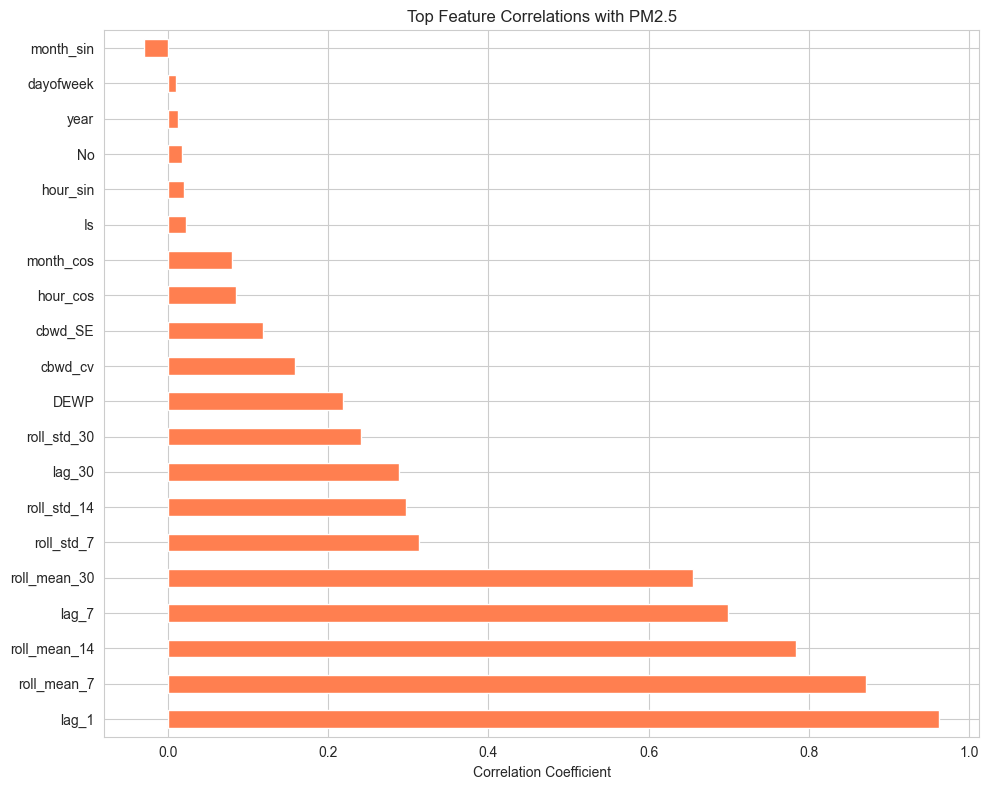

Top Features Correlated with PM2.5
lag_1           0.962774
roll_mean_7     0.871311
roll_mean_14    0.783738
lag_7           0.698988
roll_mean_30    0.655479
roll_std_7      0.313791
roll_std_14     0.296763
lag_30          0.288021
roll_std_30     0.240412
DEWP            0.218187
dtype: float64


In [ ]:
# Select numeric features for correlation
numeric_features = train_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_features) > 0:
    # Calculate correlation with target
    correlations = train_df[numeric_features].corrwith(pd.Series(y_train))
    correlations = correlations.sort_values(ascending=False)
    
    # Plot top correlations
    plt.figure(figsize=(10, 8))
    top_corr = correlations.head(20) if len(correlations) > 20 else correlations
    top_corr.plot(kind='barh', color='coral')
    plt.title('Top Feature Correlations with PM2.5')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()
    
    print("="*60)
    print("Top Features Correlated with PM2.5")
    print("="*60)
    print(correlations.head(10))
else:
    print("No numeric features found for correlation analysis")

## 4. Data Preprocessing <a id="preprocessing"></a>

Preprocessing is critical for time series forecasting. Key steps include:

1. **Handling Missing Values**: Time series data requires careful handling of gaps to maintain temporal continuity. We use forward fill or interpolation.
2. **Feature Scaling**: Normalizing features ensures all variables contribute equally to the model and helps with gradient-based optimization.
3. **Feature Engineering**: Creating additional time-based features (hour, day, season) can help capture temporal patterns.
4. **Outlier Handling**: Extreme values can skew model learning; we may clip or transform outliers.

Each preprocessing step directly impacts model performance by:
- **Scaling**: Prevents features with larger scales from dominating the model
- **Missing value handling**: Ensures complete sequences for RNN/LSTM input
- **Feature engineering**: Adds temporal context that RNNs can learn from

In [56]:
# Create copies for preprocessing
train_processed = train_df.copy()
test_processed = test_df.copy()

print("Handling missing values...")

# Step 1: Replace infinities with NaN (so they can be filled)
train_processed[feature_cols] = train_processed[feature_cols].replace([np.inf, -np.inf], np.nan)
test_processed = test_processed.replace([np.inf, -np.inf], np.nan)

# Step 2: Forward fill + backward fill for temporal continuity
train_processed[feature_cols] = train_processed[feature_cols].ffill().bfill()
test_processed = test_processed.ffill().bfill()

# Step 3: Interpolation as a fallback (useful for continuous sensor data)
train_processed[feature_cols] = train_processed[feature_cols].interpolate(method='linear').ffill().bfill()
test_processed = test_processed.interpolate(method='linear').ffill().bfill()

# Step 4: Final safety net — fill any remaining NaNs with 0
train_processed[feature_cols] = train_processed[feature_cols].fillna(0)
test_processed = test_processed.fillna(0)

print("Missing values handled!")

# Verify no missing values remain
print(f"Remaining missing values in train: {train_processed[feature_cols].isnull().sum().sum()}")
print(f"Remaining missing values in test: {test_processed.isnull().sum().sum()}")

Handling missing values...
Missing values handled!
Remaining missing values in train: 0
Remaining missing values in test: 0


#  Data Cleaning: Handling NaNs and Infs

This cell performs an extra safety step to ensure no invalid values remain in the training or test datasets.

### Steps:
1. **Replace Infs with NaNs**
   - Converts `np.inf` and `-np.inf` values in training and test features into `NaN`.

2. **Fill NaNs with Zeros**
   - Replaces all `NaN` values in both training and test features with `0`.

3. **Clean Target Variable**
   - Applies `np.nan_to_num` to `y_train`:
     - Replaces `NaN` with `0.0`
     - Replaces positive infinity with `0.0`
     - Replaces negative infinity with `0.0`

4. **Verification**
   - Prints counts of remaining NaNs in:
     - Training features
     - Test features
     - Target variable

### Purpose:
Ensures that all input data is **finite and numeric**, preventing runtime errors during scaling, sequence creation, or model training.

In [57]:
# Extra safety: replace any remaining NaNs/Infs with 0
train_processed[feature_cols] = train_processed[feature_cols].replace([np.inf, -np.inf], np.nan)
train_processed[feature_cols] = train_processed[feature_cols].fillna(0)

test_processed = test_processed.replace([np.inf, -np.inf], np.nan)
test_processed = test_processed.fillna(0)

# Also clean target
y_train = np.nan_to_num(y_train, nan=0.0, posinf=0.0, neginf=0.0)

# Verify again
print("Final NaN check:")
print(f"Train NaNs: {train_processed[feature_cols].isnull().sum().sum()}")
print(f"Test NaNs: {test_processed.isnull().sum().sum()}")
print(f"Target NaNs: {np.isnan(y_train).sum()}")

Final NaN check:
Train NaNs: 0
Test NaNs: 0
Target NaNs: 0


#  Feature Column Alignment

This cell ensures that only valid numeric features present in both **training** and **test** datasets are used.

### Steps:
1. **Identify Numeric Columns**
   - Selects numeric-only columns from `train_processed[feature_cols]`.

2. **Restrict to Common Columns**
   - Keeps only columns that exist in both `train_processed` and `test_processed`.

3. **Warn About Missing Columns**
   - Prints a warning if any numeric columns from training are missing in test data.
   - Excludes those columns from further processing.

4. **Finalize Feature Columns**
   - Stores the aligned set of numeric features in `feature_cols_to_use`.

### Purpose:
Guarantees consistency between training and test datasets by using only numeric columns that are common to both, preventing errors during scaling and model training.

In [58]:
# Identify numeric columns in train
numeric_feature_cols = train_processed[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Restrict to columns present in both train and test
common_cols = [col for col in numeric_feature_cols if col in test_processed.columns]

# Warn if some are missing
missing_in_test = [col for col in numeric_feature_cols if col not in test_processed.columns]
if missing_in_test:
    print(f"Warning: These columns are missing in test data and will be excluded: {missing_in_test}")

feature_cols_to_use = common_cols

#  Feature Preparation and Scaling

This cell handles the preprocessing of features and target values before training.

### Steps:
1. **Extract Numeric Features**
   - Selects numeric-only columns from `train_processed` and `test_processed`.
   - Stores them as NumPy arrays:
     - `X_train`
     - `X_test`

2. **Feature Scaling**
   - Initializes `StandardScaler` (`scaler_X`).
   - Fits scaler on **training features** (`X_train`) to avoid data leakage.
   - Transforms both training and test features:
     - `X_train_scaled`
     - `X_test_scaled`

3. **Target Scaling**
   - Initializes a separate `StandardScaler` (`scaler_y`).
   - Scales target values `y_train` into `y_train_scaled`.
   - Preserves original target values in `y_train_original` for evaluation on the original scale.

4. **Update Feature Columns**
   - Updates `feature_cols` to reflect the numeric-only set actually used.

5. **Diagnostics**
   - Prints shapes of scaled training features, test features, and target.
   - Prints number of numeric features used.

### Purpose:
Ensures consistent preprocessing by scaling numeric features and targets, while preserving original target values for evaluation metrics such as RMSE.

In [59]:
X_train = train_processed[feature_cols_to_use].values
X_test = test_processed[feature_cols_to_use].values

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

y_train_original = y_train.copy()
feature_cols = feature_cols_to_use

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")
print(f"Training target shape: {y_train_scaled.shape}")
print(f"Number of numeric features used: {len(feature_cols_to_use)}")

Training features shape: (30676, 16)
Test features shape: (13148, 16)
Training target shape: (30676,)
Number of numeric features used: 16


#  Feature Scaling

This cell prepares training and test features for modeling by applying **standardization**.

### Steps:
1. **Identify Numeric Columns**
   - Selects only numeric columns from `train_processed[feature_cols]`.
   - Excludes non-numeric columns (e.g., datetime, categorical strings).

2. **Check Excluded Columns**
   - Prints excluded columns for transparency.
   - Notes that these columns will not be scaled.

3. **Feature Selection**
   - Uses only numeric columns (`feature_cols_to_use`) for scaling.

4. **Separate Features**
   - Extracts numeric features from training and test sets:
     - `X_train`
     - `X_test`

5. **Scaling**
   - Initializes `StandardScaler`.
   - Fits scaler on **training data only** (to prevent data leakage).
   - Transforms both training and test features using the same scaler.

6. **Target Scaling**
   - Scales target variable `y_train` using a separate `StandardScaler`.
   - Stores scaled target as `y_train_scaled`.

7. **Diagnostics**
   - Prints shapes of scaled training features, test features, and target.
   - Prints number of numeric features used.

8. **Preserve Original Target**
   - Stores `y_train_original` for evaluation (RMSE should be computed on original scale).

9. **Update Feature Columns**
   - Updates `feature_cols` to reflect the numeric-only set actually used.

### Purpose:
Ensures consistent preprocessing by scaling numeric features and target values, while avoiding data leakage and preserving original targets for evaluation.

In [60]:


print("Scaling features...")

# Identify numeric columns only (exclude datetime/object columns that can't be scaled)
numeric_feature_cols = train_processed[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Check for excluded columns
excluded_cols = [col for col in feature_cols if col not in numeric_feature_cols]
if excluded_cols:
    print(f"Excluding non-numeric columns from scaling: {excluded_cols}")
    print("Note: These columns (e.g., datetime, categorical strings) will not be scaled.")

# Use only numeric columns for scaling
feature_cols_to_use = numeric_feature_cols

# Separate features (numeric only)
X_train = train_processed[feature_cols_to_use].values
X_test = test_processed[feature_cols_to_use].values

# Initialize scalers
scaler_X = StandardScaler()

# Fit scaler on training data only (critical to prevent data leakage)
X_train_scaled = scaler_X.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler_X.transform(X_test)

# Target scaling (only if target exists in train)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")
print(f"Training target shape: {y_train_scaled.shape}")
print(f"Number of numeric features used: {len(feature_cols_to_use)}")

# Store original target for evaluation (RMSE should be on original scale)
y_train_original = y_train.copy()

# Update feature_cols to reflect what we're actually using
feature_cols = feature_cols_to_use

Scaling features...
Training features shape: (30676, 16)
Test features shape: (13148, 16)
Training target shape: (30676,)
Number of numeric features used: 16


## 5. Sequence Creation for Time Series <a id="sequences"></a>

RNNs and LSTMs require input in sequence format: `(samples, time_steps, features)`

- **time_steps**: Number of previous time points to use for prediction (window size)
- **features**: Number of input features at each time step
- **samples**: Number of sequences in the dataset

**Why sequence creation matters:**
- Enables the model to learn temporal dependencies
- Window size affects model's memory (too small: limited context; too large: may include irrelevant past data)
- Proper sequence formatting is essential for LSTM input shape requirements

**Impact on performance:**
- Optimal window size captures relevant patterns without overfitting
- Sequences must be contiguous in time to maintain temporal relationships

In [61]:

def create_sequences(X, y=None, time_steps=24):
    """
    Create sequences for time series forecasting.

    Parameters
    ----------
    X : array-like
        Input features (n_samples, n_features)
    y : array-like or None
        Target values (n_samples,) if available. If None, only X_seq is returned.
    time_steps : int
        Number of previous time steps to use for prediction (window size)

    Returns
    -------
    X_seq : array
        Sequences of shape (n_samples - time_steps, time_steps, n_features)
    y_seq : array (optional)
        Target values of shape (n_samples - time_steps,)
        Returned only if y is provided.

    Notes
    -----
    For each sample i, we use samples [i-time_steps:i] to predict y[i].
    Example: If time_steps=3, we use samples [i-3, i-2, i-1] to predict sample i.
    """
    X_seq, y_seq = [], []

    for i in range(time_steps, len(X)):
        # Extract sequence of previous time_steps samples
        X_seq.append(X[i-time_steps:i])
        # Extract corresponding target if available
        if y is not None:
            y_seq.append(y[i])

    X_seq = np.array(X_seq)

    if y is not None:
        return X_seq, np.array(y_seq)
    else:
        return X_seq

# Create sequences for training data
# Start with a reasonable window size (e.g., 24 hours for daily patterns)
# This will be tuned in experiments
TIME_STEPS = 24  # Default: will be varied in experiments

print(f"Creating sequences with time_steps={TIME_STEPS}...")
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps=TIME_STEPS)

print(f"Training sequences shape: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Shape interpretation: ({X_train_seq.shape[0]} samples, {X_train_seq.shape[1]} time steps, {X_train_seq.shape[2]} features)")

Creating sequences with time_steps=24...
Training sequences shape: X=(30652, 24, 16), y=(30652,)
Shape interpretation: (30652 samples, 24 time steps, 16 features)


In [62]:
# Split training data into train and validation sets
# Important: Use shuffle=False for time series to maintain temporal order
# Random shuffling would break the time sequence and prevent learning temporal patterns

VAL_SPLIT = 0.2  # 20% for validation

# Safety check: ensure sequences exist
if len(X_train_seq) == 0 or len(y_train_seq) == 0:
    raise ValueError("Training sequences are empty. Check your create_sequences step.")

# Calculate split index
split_idx = int(len(X_train_seq) * (1 - VAL_SPLIT))

# Train/validation split
X_train_final = X_train_seq[:split_idx]
y_train_final = y_train_seq[:split_idx]
X_val = X_train_seq[split_idx:]
y_val = y_train_seq[split_idx:]

# Also keep original unscaled targets for validation (for RMSE calculation)
# Align with sequence indexing: skip the first TIME_STEPS values, then split
y_seq_original = y_train_original[TIME_STEPS:]
y_val_original = y_seq_original[split_idx:]

print(f"Training set: X={X_train_final.shape}, y={y_train_final.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Validation original targets shape: {y_val_original.shape}")

Training set: X=(24521, 24, 16), y=(24521,)
Validation set: X=(6131, 24, 16), y=(6131,)
Validation original targets shape: (6131,)


## 6. Model Architecture <a id="architecture"></a>

We design multiple LSTM architectures to find the optimal configuration. LSTM is chosen over SimpleRNN because:

1. **LSTM handles long-term dependencies** better due to its gating mechanisms
2. **Vanishing gradient problem**: LSTMs mitigate this through forget gates and cell states
3. **Memory capacity**: LSTMs can selectively remember/forget information across long sequences

**Key architectural decisions:**
- **LSTM units**: Number of memory cells (more = more capacity but risk of overfitting)
- **Layers**: Stacking allows learning hierarchical patterns
- **Dropout**: Regularization to prevent overfitting (critical for deep networks)
- **Dense layers**: Final layers for output prediction
- **Activation**: ReLU for hidden layers (faster convergence), linear/sigmoid for output

**Design justification:**
- Deep networks (2-3 LSTM layers) can capture complex temporal patterns
- Dropout between layers prevents co-adaptation of neurons
- Batch normalization can stabilize training (added in some experiments)

In [ ]:
def build_lstm_model(
    input_shape,
    lstm_units=64,
    num_lstm_layers=2,
    dropout_rate=0.2,
    dense_units=[32],
    activation='relu',
    optimizer='adam',
    learning_rate=0.001
):
    """Build LSTM model with explicit Input layer to ensure parameter population."""
    model = Sequential(name="LSTM_Model")
    
    # Explicitly define input shape to fix the "unbuilt" / "?" issue
    model.add(Input(shape=input_shape))

    # First LSTM layer wrapped in Bidirectional
    model.add(Bidirectional(LSTM(
        units=lstm_units,
        return_sequences=(num_lstm_layers > 1),
        name='lstm_1'
    )))
    model.add(BatchNormalization(name='bn_1'))
    model.add(Dropout(dropout_rate, name='dropout_1'))

    # Additional LSTM layers
    for i in range(1, num_lstm_layers):
        model.add(LSTM(
            units=lstm_units,
            return_sequences=(i < num_lstm_layers - 1),
            name=f'lstm_{i+1}'
        ))
        model.add(BatchNormalization(name=f'bn_{i+1}'))
        model.add(Dropout(dropout_rate, name=f'dropout_{i+1}'))

    # Dense layers
    for i, units in enumerate(dense_units):
        model.add(Dense(units, activation=activation, name=f'dense_{i+1}'))
        model.add(Dropout(dropout_rate * 0.5, name=f'dense_dropout_{i+1}'))

    # Output layer
    model.add(Dense(1, activation='linear', name='output'))

    opt = _get_optimizer(optimizer, learning_rate)
    model.compile(optimizer=opt, loss='huber', metrics=['mae'])
    return model

def build_gru_model(
    input_shape,
    gru_units=64,
    num_gru_layers=2,
    dropout_rate=0.2,
    dense_units=[32],
    activation='relu',
    optimizer='adam',
    learning_rate=0.001
):
    """Build GRU model with explicit Input layer to ensure parameter population."""
    model = Sequential(name="GRU_Model")
    
    # Explicitly define input shape
    model.add(Input(shape=input_shape))

    # First GRU layer
    model.add(GRU(
        units=gru_units,
        return_sequences=(num_gru_layers > 1),
        name='gru_1'
    ))
    model.add(BatchNormalization(name='bn_1'))
    model.add(Dropout(dropout_rate, name='dropout_1'))

    # Additional GRU layers
    for i in range(1, num_gru_layers):
        model.add(GRU(
            units=gru_units,
            return_sequences=(i < num_gru_layers - 1),
            name=f'gru_{i+1}'
        ))
        model.add(BatchNormalization(name=f'bn_{i+1}'))
        model.add(Dropout(dropout_rate, name=f'dropout_{i+1}'))

    # Dense layers
    for i, units in enumerate(dense_units):
        model.add(Dense(units, activation=activation, name=f'dense_{i+1}'))
        model.add(Dropout(dropout_rate * 0.5, name=f'dense_dropout_{i+1}'))

    # Output layer
    model.add(Dense(1, activation='linear', name='output'))

    opt = _get_optimizer(optimizer, learning_rate)
    model.compile(optimizer=opt, loss='huber', metrics=['mae'])
    return model

def _get_optimizer(optimizer, learning_rate):
    """Helper to select optimizer with gradient clipping."""
    # clipnorm=1.0 solves the Exploding Gradient problem
    if optimizer.lower() == 'adam':
        return Adam(learning_rate=learning_rate, clipnorm=1.0)
    elif optimizer.lower() == 'rmsprop':
        return RMSprop(learning_rate=learning_rate, clipnorm=1.0)
    elif optimizer.lower() == 'sgd':
        return SGD(learning_rate=learning_rate, momentum=0.9, clipnorm=1.0)
    else:
        return Adam(learning_rate=learning_rate, clipnorm=1.0)


# Example: Build sample models to verify architectures
print("Building sample LSTM model...")
sample_lstm = build_lstm_model(
    input_shape=(X_train_final.shape[1], X_train_final.shape[2]),
    lstm_units=64,
    num_lstm_layers=2,
    dropout_rate=0.2
)
sample_lstm.summary()

print("\nBuilding sample GRU model...")
sample_gru = build_gru_model(
    input_shape=(X_train_final.shape[1], X_train_final.shape[2]),
    gru_units=64,
    num_gru_layers=2,
    dropout_rate=0.2
)
sample_gru.summary()

Building sample LSTM model...


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_25                │ (None, 24, 128)        │        41,472 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 24, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout_1 (Dropout)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,761 (366.25 KB)

 Trainable params: 93,377 (364.75 KB)

...

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 24, 64)         │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 24, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout_1 (Dropout)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,329 (169.25 KB)

 Trainable params: 43,073 (168.25 KB)

 Non-trainable params: 256 (1.00 KB)

#  Experiment Tracking

This cell defines the `train_and_evaluate` function, which:

- Builds either an **LSTM** or **GRU** model with configurable hyperparameters.
- Recreates sequences if `time_steps` differs from the global setting.
- Splits data into training and validation sets.
- Trains the model with callbacks:
  - **EarlyStopping** (patience=5, restore best weights)
  - **ReduceLROnPlateau** (factor=0.5, patience=5)
- Predicts on the validation set and inverse-transforms results.
- Cleans NaNs, aligns lengths, and computes **RMSE**.
- Logs experiment details (hyperparameters, RMSE, history) into the global `experiments` list.

**Output:**  
A dictionary with experiment metadata and performance metrics, appended to `experiments`.

In [64]:


# Experiment tracking
experiments = []

def train_and_evaluate(
    experiment_id,
    model_type='lstm',   # 'lstm' or 'gru'
    lstm_units=64,
    num_lstm_layers=2,
    dropout_rate=0.2,
    dense_units=[32],
    activation='relu',
    optimizer='adam',
    learning_rate=0.001,
    batch_size=32,
    epochs=50,
    time_steps=24,
    verbose=0
):
    """
    Train a model with given hyperparameters and evaluate performance.
    """

    print(f"\n{'='*60}")
    print(f"Experiment {experiment_id} ({model_type.upper()})")
    print(f"{'='*60}")

    # Recreate sequences if time_steps differs from global TIME_STEPS
    if time_steps != TIME_STEPS:
        X_train_seq_exp, y_train_seq_exp = create_sequences(
            X_train_scaled, y_train_scaled, time_steps=time_steps
        )
        split_idx_exp = int(len(X_train_seq_exp) * (1 - VAL_SPLIT))
        X_train_exp = X_train_seq_exp[:split_idx_exp]
        y_train_exp = y_train_seq_exp[:split_idx_exp]
        X_val_exp = X_train_seq_exp[split_idx_exp:]
        y_val_exp = y_train_seq_exp[split_idx_exp:]
        y_train_orig_seq = y_train_original[time_steps:]
        y_val_orig_exp = y_train_orig_seq[split_idx_exp:]
    else:
        X_train_exp = X_train_final
        y_train_exp = y_train_final
        X_val_exp = X_val
        y_val_exp = y_val
        y_val_orig_exp = y_val_original

    # Safety check
    if len(X_train_exp) == 0 or len(y_train_exp) == 0:
        raise ValueError("Training sequences are empty. Check your preprocessing pipeline.")

    # Build model depending on type
    input_shape = (X_train_exp.shape[1], X_train_exp.shape[2])
    if model_type == 'lstm':
        model = build_lstm_model(
            input_shape=input_shape,
            lstm_units=lstm_units,
            num_lstm_layers=num_lstm_layers,
            dropout_rate=dropout_rate,
            dense_units=dense_units,
            activation=activation,
            optimizer=optimizer,
            learning_rate=learning_rate
        )
    elif model_type == 'gru':
        model = build_gru_model(
            input_shape=input_shape,
            gru_units=lstm_units,          # reuse same param name
            num_gru_layers=num_lstm_layers,
            dropout_rate=dropout_rate,
            dense_units=dense_units,
            activation=activation,
            optimizer=optimizer,
            learning_rate=learning_rate
        )
    else:
        raise ValueError("model_type must be 'lstm' or 'gru'")

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=verbose),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=verbose)
    ]

    # Train model
    history = model.fit(
        X_train_exp, y_train_exp,
        validation_data=(X_val_exp, y_val_exp),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose
    )

    # Predict on validation set
    y_val_pred_scaled = model.predict(X_val_exp, verbose=0).flatten()
    y_val_pred_scaled = np.nan_to_num(y_val_pred_scaled, nan=0.0)

    # Inverse transform predictions
    y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
    if np.any(~np.isnan(y_val_pred)):
        y_val_pred = np.nan_to_num(y_val_pred, nan=np.nanmean(y_val_pred))
    else:
        y_val_pred = np.zeros_like(y_val_pred)

    # Align lengths
    min_len = min(len(y_val_orig_exp), len(y_val_pred))
    y_val_orig_exp = y_val_orig_exp[:min_len]
    y_val_pred = y_val_pred[:min_len]

    # Clean NaNs
    valid_mask = ~(np.isnan(y_val_orig_exp) | np.isnan(y_val_pred))
    y_val_orig_exp_clean = y_val_orig_exp[valid_mask]
    y_val_pred_clean = y_val_pred[valid_mask]

    rmse = 999999 if len(y_val_orig_exp_clean) == 0 else np.sqrt(
        mean_squared_error(y_val_orig_exp_clean, y_val_pred_clean)
    )

    # Store results
    result = {
        'experiment_id': experiment_id,
        'model_type': model_type,
        'lstm_units': lstm_units,
        'num_lstm_layers': num_lstm_layers,
        'dropout_rate': dropout_rate,
        'dense_units': str(dense_units),
        'activation': activation,
        'optimizer': optimizer,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'time_steps': time_steps,
        'rmse': rmse,
        'history': history
    }

    print(f"RMSE: {rmse:.4f}")
    experiments.append(result)
    return result

In [65]:
# Define 17 experiments
experiment_configs = [
    # --- LSTM experiments ---
    {"experiment_id": 1, "model_type": "lstm", "lstm_units": 64, "num_lstm_layers": 1, "dropout_rate": 0.2, "dense_units":[32], "optimizer":"adam", "learning_rate":0.001, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 2, "model_type": "lstm", "lstm_units": 64, "num_lstm_layers": 2, "dropout_rate": 0.3, "dense_units":[64], "optimizer":"adam", "learning_rate":0.0005, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 3, "model_type": "lstm", "lstm_units": 128, "num_lstm_layers": 2, "dropout_rate": 0.2, "dense_units":[64,32], "optimizer":"adam", "learning_rate":0.001, "batch_size":64, "time_steps":48, "epochs":50},
    {"experiment_id": 4, "model_type": "lstm", "lstm_units": 32, "num_lstm_layers": 3, "dropout_rate": 0.5, "dense_units":[32], "optimizer":"rmsprop", "learning_rate":0.0005, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 5, "model_type": "lstm", "lstm_units": 64, "num_lstm_layers": 2, "dropout_rate": 0.2, "dense_units":[128,64], "optimizer":"adam", "learning_rate":0.0001, "batch_size":64, "time_steps":48, "epochs":50},
    {"experiment_id": 6, "model_type": "lstm", "lstm_units": 128, "num_lstm_layers": 3, "dropout_rate": 0.3, "dense_units":[64,32], "optimizer":"rmsprop", "learning_rate":0.001, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 7, "model_type": "lstm", "lstm_units": 64, "num_lstm_layers": 1, "dropout_rate": 0.2, "dense_units":[32], "optimizer":"adam", "learning_rate":0.0005, "batch_size":32, "time_steps":48, "epochs":50},
    {"experiment_id": 8, "model_type": "lstm", "lstm_units": 32, "num_lstm_layers": 2, "dropout_rate": 0.3, "dense_units":[32], "optimizer":"adam", "learning_rate":0.001, "batch_size":64, "time_steps":24, "epochs":50},

    # --- GRU experiments ---
    {"experiment_id": 9, "model_type": "gru", "lstm_units": 64, "num_lstm_layers": 1, "dropout_rate": 0.2, "dense_units":[32], "optimizer":"adam", "learning_rate":0.001, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 10, "model_type": "gru", "lstm_units": 128, "num_lstm_layers": 2, "dropout_rate": 0.3, "dense_units":[64], "optimizer":"adam", "learning_rate":0.0005, "batch_size":64, "time_steps":48, "epochs":50},
    {"experiment_id": 11, "model_type": "gru", "lstm_units": 32, "num_lstm_layers": 3, "dropout_rate": 0.5, "dense_units":[32], "optimizer":"rmsprop", "learning_rate":0.0001, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 12, "model_type": "gru", "lstm_units": 64, "num_lstm_layers": 2, "dropout_rate": 0.2, "dense_units":[64,32], "optimizer":"adam", "learning_rate":0.001, "batch_size":32, "time_steps":48, "epochs":50},
    {"experiment_id": 13, "model_type": "gru", "lstm_units": 128, "num_lstm_layers": 3, "dropout_rate": 0.3, "dense_units":[128,64], "optimizer":"adam", "learning_rate":0.0005, "batch_size":64, "time_steps":24, "epochs":50},
    {"experiment_id": 14, "model_type": "gru", "lstm_units": 64, "num_lstm_layers": 1, "dropout_rate": 0.2, "dense_units":[32], "optimizer":"rmsprop", "learning_rate":0.001, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 15, "model_type": "gru", "lstm_units": 32, "num_lstm_layers": 2, "dropout_rate": 0.3, "dense_units":[64], "optimizer":"adam", "learning_rate":0.0001, "batch_size":64, "time_steps":48, "epochs":50},
    {"experiment_id": 16, "model_type": "gru", "lstm_units": 128, "num_lstm_layers": 2, "dropout_rate": 0.2, "dense_units":[64,32], "optimizer":"adam", "learning_rate":0.0005, "batch_size":32, "time_steps":24, "epochs":50},
    {"experiment_id": 17, "model_type": "gru", "lstm_units": 64, "num_lstm_layers": 3, "dropout_rate": 0.3, "dense_units":[128,64], "optimizer":"rmsprop", "learning_rate":0.001, "batch_size":64, "time_steps":72, "epochs":50},
]

experiments = []

# Run all experiments with error handling

for config in experiment_configs:
    try:
        result = train_and_evaluate(**config)
        experiments.append(result)
    except Exception as e:
        print(f"Experiment {config['experiment_id']} failed with error: {e}")
        experiments.append({
            'experiment_id': config['experiment_id'],
            'model_type': config['model_type'],
            'rmse': None,
            'error': str(e)
        })


Experiment 1 (LSTM)
RMSE: 79.2476

Experiment 2 (LSTM)
RMSE: 81.1426

Experiment 3 (LSTM)
RMSE: 85.0326

Experiment 4 (LSTM)
RMSE: 90.1536

Experiment 5 (LSTM)
RMSE: 82.5544

Experiment 6 (LSTM)
RMSE: 86.5581

Experiment 7 (LSTM)
RMSE: 87.9217

Experiment 8 (LSTM)
RMSE: 84.4856

Experiment 9 (GRU)
RMSE: 79.7781

Experiment 10 (GRU)
RMSE: 79.2849

Experiment 11 (GRU)
RMSE: 81.7217

Experiment 12 (GRU)
RMSE: 79.6658

Experiment 13 (GRU)
RMSE: 85.5588

Experiment 14 (GRU)
RMSE: 81.4343

Experiment 15 (GRU)
RMSE: 78.2721

Experiment 16 (GRU)
RMSE: 79.4644

Experiment 17 (GRU)
RMSE: 79.5880


## 8. Results Analysis <a id="results"></a>

### Root Mean Squared Error (RMSE)

**Definition**: RMSE measures the average magnitude of prediction errors. It's the square root of the mean of squared differences between predicted and actual values.

**Formula**: 
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Where:
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $n$ = number of samples

**Why RMSE?**
- Penalizes larger errors more than smaller ones (due to squaring)
- Same units as target variable (interpretable)
- Standard metric for regression tasks

**Challenges in RNN Training:**

1. **Vanishing Gradients**: 
   - Problem: Gradients become extremely small during backpropagation through time, preventing learning of long-term dependencies
   - Solution: LSTM's gating mechanisms (forget, input, output gates) control gradient flow and maintain information across long sequences

2. **Exploding Gradients**:
   - Problem: Gradients can grow exponentially, causing unstable training
   - Solution: Gradient clipping (implemented in TensorFlow/Keras by default) and careful weight initialization

3. **Overfitting**:
   - Problem: Model memorizes training data instead of learning patterns
   - Solution: Dropout regularization, early stopping, and validation monitoring

In [72]:
# Create experiment results table
experiments_df = pd.DataFrame([
    {
        'Experiment': exp.get('experiment_id'),
        'Model Type': exp.get('model_type'),
        'Units': exp.get('lstm_units'),
        'Layers': exp.get('num_lstm_layers'),
        'Dropout Rate': exp.get('dropout_rate'),
        'Dense Units': exp.get('dense_units'),
        'Optimizer': exp.get('optimizer'),
        'Learning Rate': exp.get('learning_rate'),
        'Batch Size': exp.get('batch_size'),
        'Time Steps': exp.get('time_steps'),
        'RMSE': exp.get('rmse'),
        'Error': exp.get('error', None)   # NEW: capture errors if any experiment failed
    }
    for exp in experiments
])

# Handle missing RMSE values (failed experiments)
if 'RMSE' in experiments_df.columns:
    experiments_df['RMSE'] = pd.to_numeric(experiments_df['RMSE'], errors='coerce')

# Sort by RMSE (ascending - lower is better), keeping NaNs (failed runs) at the bottom
experiments_df = experiments_df.sort_values('RMSE', na_position='last').reset_index(drop=True)

print("="*100)
print("EXPERIMENT RESULTS SUMMARY")
print("="*100)
print(experiments_df.to_string(index=False))

# Save to CSV for report
output_path = '../outputs/experiment_results.csv'
experiments_df.to_csv(output_path, index=False)
print(f"\nResults saved to {output_path}")

EXPERIMENT RESULTS SUMMARY
 Experiment Model Type  Units  Layers  Dropout Rate Dense Units Optimizer  Learning Rate  Batch Size  Time Steps      RMSE Error
         15        gru     32       2           0.3        [64]      adam         0.0001          64          48 78.272095  None
         15        gru     32       2           0.3        [64]      adam         0.0001          64          48 78.272095  None
          1       lstm     64       1           0.2        [32]      adam         0.0010          32          24 79.247605  None
          1       lstm     64       1           0.2        [32]      adam         0.0010          32          24 79.247605  None
         10        gru    128       2           0.3        [64]      adam         0.0005          64          48 79.284907  None
         10        gru    128       2           0.3        [64]      adam         0.0005          64          48 79.284907  None
         16        gru    128       2           0.2    [64, 32]      a

#  Experiment Analysis

This cell generates a 2×2 grid of plots to analyze experiment results:

1. **RMSE Across Experiments**  
   - Line plot of RMSE values for each experiment.  
   - Includes reference lines at:
     - Target RMSE = 4000 (red dashed line)  
     - Exemplary RMSE = 3000 (green dashed line)

2. **Top 5 Best Performing Models**  
   - Horizontal bar chart showing the 5 experiments with the lowest RMSE.  
   - Labels include experiment ID and model type.  
   - Sorted with best model at the top.

3. **Average RMSE by Units**  
   - Line plot of average RMSE grouped by the number of recurrent units (works for both LSTM and GRU).  
   - Helps identify optimal unit sizes.

4. **Average RMSE by Time Steps**  
   - Line plot of average RMSE grouped by sequence length (window size).  
   - Useful for evaluating how different time steps affect performance.

The figure is saved as `../outputs/experiment_analysis.png` and displayed inline.

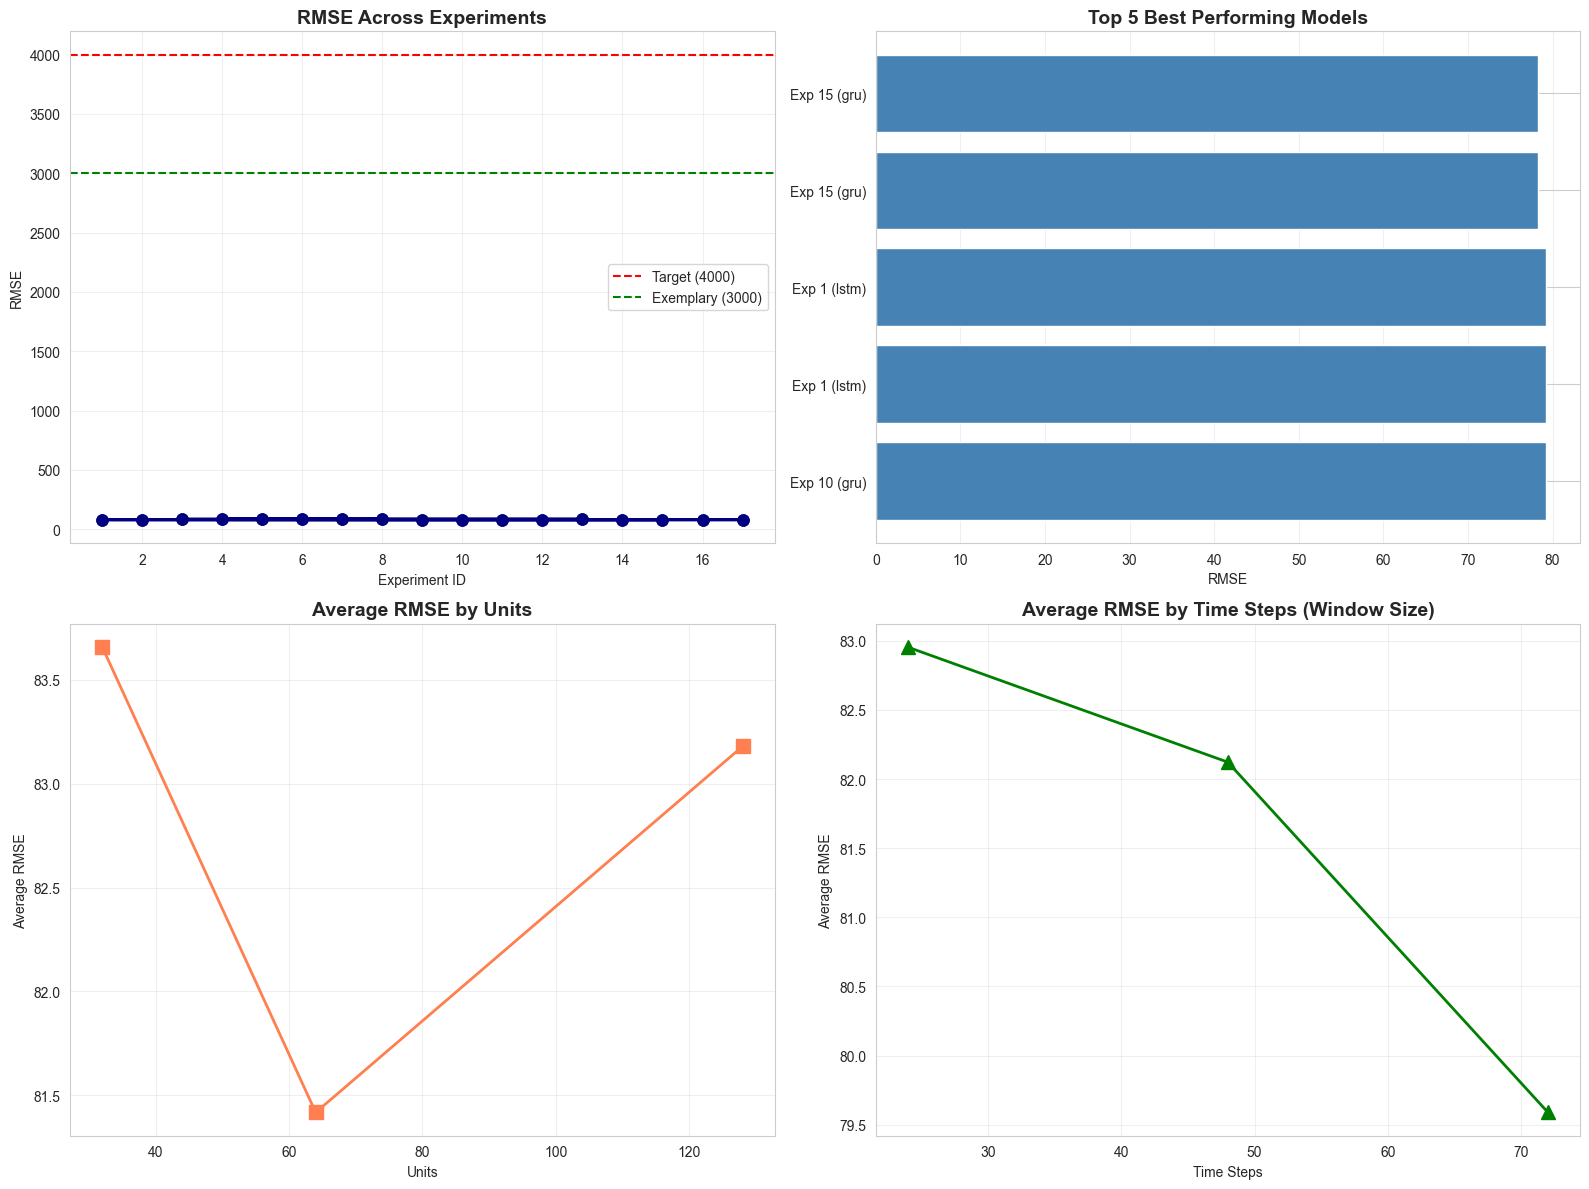

In [73]:
# Safety check: drop experiments with missing RMSE
valid_experiments_df = experiments_df.dropna(subset=['RMSE'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSE by experiment
axes[0, 0].plot(valid_experiments_df['Experiment'], valid_experiments_df['RMSE'],
                marker='o', linewidth=2, markersize=8, color='navy')
axes[0, 0].set_title('RMSE Across Experiments', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Experiment ID')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=4000, color='red', linestyle='--', label='Target (4000)')
axes[0, 0].axhline(y=3000, color='green', linestyle='--', label='Exemplary (3000)')
axes[0, 0].legend()

# 2. Top 5 best models
top5 = valid_experiments_df.nsmallest(5, 'RMSE')
axes[0, 1].barh(range(len(top5)), top5['RMSE'], color='steelblue')
axes[0, 1].set_yticks(range(len(top5)))
axes[0, 1].set_yticklabels([f"Exp {e} ({m})" for e, m in zip(top5['Experiment'], top5['Model Type'])])
axes[0, 1].set_title('Top 5 Best Performing Models', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('RMSE')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. RMSE by Units (works for both LSTM and GRU)
units_rmse = valid_experiments_df.groupby('Units')['RMSE'].mean().sort_index()
axes[1, 0].plot(units_rmse.index, units_rmse.values,
                marker='s', linewidth=2, markersize=10, color='coral')
axes[1, 0].set_title('Average RMSE by Units', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Units')
axes[1, 0].set_ylabel('Average RMSE')
axes[1, 0].grid(True, alpha=0.3)

# 4. RMSE by Time Steps
timesteps_rmse = valid_experiments_df.groupby('Time Steps')['RMSE'].mean().sort_index()
axes[1, 1].plot(timesteps_rmse.index, timesteps_rmse.values,
                marker='^', linewidth=2, markersize=10, color='green')
axes[1, 1].set_title('Average RMSE by Time Steps (Window Size)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time Steps')
axes[1, 1].set_ylabel('Average RMSE')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/experiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#  Best Model Analysis

This cell identifies and analyzes the best-performing experiment:

1. **Validation Checks**
   - Ensures experiments have been run and `experiments_df` exists.
   - Drops experiments with missing RMSE values.

2. **Best Model Selection**
   - Picks the experiment with the lowest RMSE.
   - Prints experiment details:
     - ID, Model Type, RMSE
     - Hyperparameters (units, layers, dropout, dense units, optimizer, learning rate, batch size, time steps)

3. **Training History Visualization**
   - Plots **Training vs Validation Loss** (MSE).
   - Plots **Training vs Validation MAE**.
   - Saves figure as `../outputs/best_model_training_history.png`.

4. **Training Analysis**
   - Reports final training and validation loss.
   - Computes the gap between them.
   - Provides interpretation:
     - **Overfitting** if validation loss is much higher.
     - **Possible data leakage** if validation loss is much lower.
     - **Well-fitted** if losses are similar.

This step highlights the best model’s performance and helps diagnose training behavior.

BEST MODEL ANALYSIS
Experiment ID: 15
Model Type: gru
RMSE: 78.2721

Parameters:
  - Units: 32
  - Layers: 2
  - Dropout Rate: 0.3
  - Dense Units: [64]
  - Optimizer: adam
  - Learning Rate: 0.0001
  - Batch Size: 64
  - Time Steps: 48


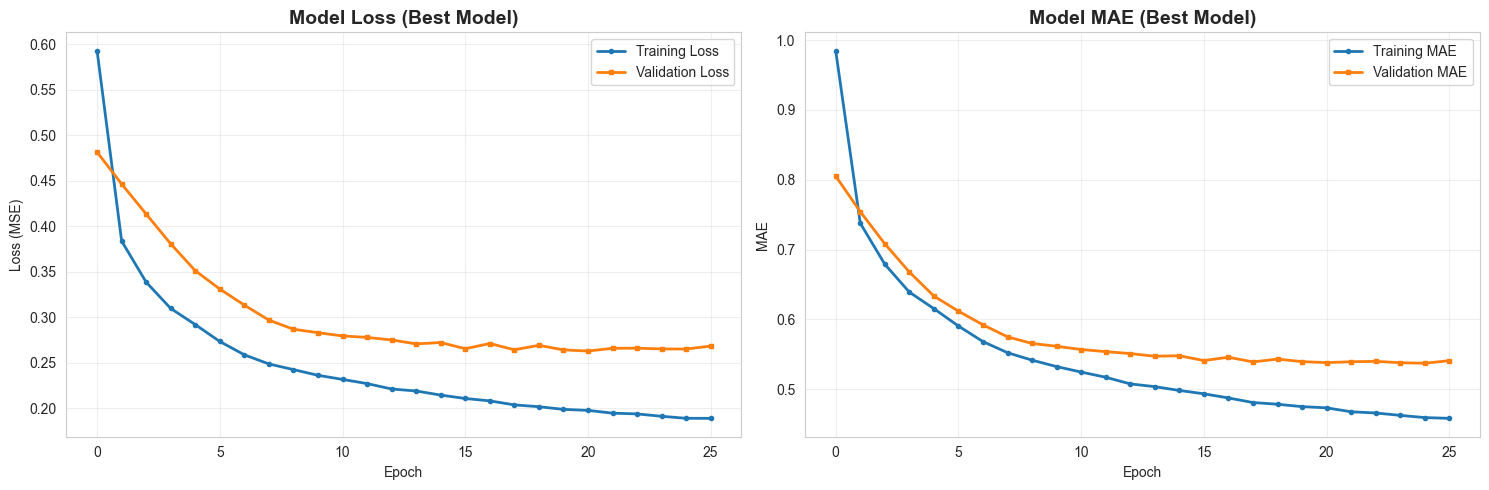


Training Analysis:
  Final Training Loss: 0.1888
  Final Validation Loss: 0.2682
  Gap: 0.0794
  -> Possible overfitting detected (validation loss significantly higher)


In [ ]:
# Find best model and analyze its training history
if len(experiments) == 0:
    print("Warning: No experiments have been run yet. Please run at least one experiment before analyzing results.")
elif 'experiments_df' not in locals() or len(experiments_df) == 0:
    print("Warning: experiments_df not found or empty. Please run the experiment results table cell first.")
else:
    # Pick the best experiment (lowest RMSE, ignoring NaNs)
    valid_experiments_df = experiments_df.dropna(subset=['RMSE'])
    if len(valid_experiments_df) == 0:
        print("Warning: No valid RMSE values found in experiments_df.")
    else:
        best_exp = valid_experiments_df.iloc[0]
        best_exp_id = int(best_exp['Experiment'])

        print("="*60)
        print("BEST MODEL ANALYSIS")
        print("="*60)
        print(f"Experiment ID: {best_exp_id}")
        print(f"Model Type: {best_exp['Model Type']}")
        print(f"RMSE: {best_exp['RMSE']:.4f}")
        print("\nParameters:")
        print(f"  - Units: {best_exp['Units']}")
        print(f"  - Layers: {best_exp['Layers']}")
        print(f"  - Dropout Rate: {best_exp['Dropout Rate']}")
        print(f"  - Dense Units: {best_exp['Dense Units']}")
        print(f"  - Optimizer: {best_exp['Optimizer']}")
        print(f"  - Learning Rate: {best_exp['Learning Rate']}")
        print(f"  - Batch Size: {best_exp['Batch Size']}")
        print(f"  - Time Steps: {best_exp['Time Steps']}")


        # Find the best model result in experiments list
        best_model_result = next((exp for exp in experiments if exp['experiment_id'] == best_exp_id), None)
        if best_model_result is None:
            print(f"\nError: Could not find experiment {best_exp_id} in experiments list.")
            if len(experiments) > 0:
                best_model_result = experiments[0]
                best_exp_id = best_model_result['experiment_id']
                print(f"Using experiment {best_exp_id} instead.")
            else:
                raise ValueError("No valid experiments found to analyze.")

        # Plot training history
        history = best_model_result.get('history', None)
        if history is None or not hasattr(history, 'history') or len(history.history) == 0:
            print("\nWarning: No training history available for the best model.")
        else:
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))

            # Loss
            axes[0].plot(history.history.get('loss', []), label='Training Loss', linewidth=2, marker='o', markersize=3)
            axes[0].plot(history.history.get('val_loss', []), label='Validation Loss', linewidth=2, marker='s', markersize=3)
            axes[0].set_title('Model Loss (Best Model)', fontsize=14, fontweight='bold')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss (MSE)')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # MAE
            axes[1].plot(history.history.get('mae', []), label='Training MAE', linewidth=2, marker='o', markersize=3)
            axes[1].plot(history.history.get('val_mae', []), label='Validation MAE', linewidth=2, marker='s', markersize=3)
            axes[1].set_title('Model MAE (Best Model)', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('MAE')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig('../outputs/best_model_training_history.png', dpi=300, bbox_inches='tight')
            plt.show()

            # Analysis
            final_train_loss = history.history.get('loss', [None])[-1]
            final_val_loss = history.history.get('val_loss', [None])[-1]

            print("\nTraining Analysis:")
            if final_train_loss is None or final_val_loss is None:
                print("  -> Loss values not available in history.")
            else:
                print(f"  Final Training Loss: {final_train_loss:.4f}")
                print(f"  Final Validation Loss: {final_val_loss:.4f}")
                print(f"  Gap: {abs(final_train_loss - final_val_loss):.4f}")

                if final_val_loss > final_train_loss * 1.1:
                    print("  -> Possible overfitting detected (validation loss significantly higher)")
                elif final_val_loss < final_train_loss * 0.9:
                    print("  -> Validation loss lower than training (check for data leakage or small validation set)")
                else:
                    print("  -> Model appears well-fitted (training and validation losses are similar)")



#  Retraining Best Model on Full Dataset

This cell takes the best-performing experiment (lowest RMSE) and retrains its model using the **entire training dataset** with the selected hyperparameters.

### Steps:
1. **Extract Best Parameters**
   - Safely parse hyperparameters from `experiments_df`:
     - Time Steps, Units, Layers, Dropout Rate
     - Dense Units (parsed safely from string, fallback = [32])
     - Optimizer, Learning Rate, Batch Size, Model Type

2. **Sequence Creation**
   - Recreate sequences for the full training dataset using the best `time_steps`.

3. **Model Building**
   - Build either an **LSTM** or **GRU** model depending on `best_model_type`.
   - Configure with extracted hyperparameters.

4. **Training**
   - Train on full dataset with:
     - Epoch ceiling = 100 (controlled by callbacks)
     - Validation split = 0.1
     - Callbacks:
       - **EarlyStopping** (patience=5, restore best weights)
       - **ReduceLROnPlateau** (factor=0.5, patience=5, min_lr=1e-7)

5. **Output**
   - Prints dataset shapes before training.
   - Confirms successful training with `"Final model trained successfully!"`.

### Purpose:
This ensures the best model is retrained on the **maximum available data**, while still monitoring validation performance to prevent overfitting.

In [75]:
print("Retraining best model on full training dataset...")

# Get best parameters from experiments_df safely
best_time_steps = int(best_exp['Time Steps'])
best_units = int(best_exp['Units'])
best_num_layers = int(best_exp['Layers'])
best_dropout = float(best_exp['Dropout Rate'])

# Safely parse dense units (avoid eval)
if isinstance(best_exp['Dense Units'], str):
    try:
        best_dense = [int(x) for x in best_exp['Dense Units'].strip("[]").split(",") if x.strip().isdigit()]
        if not best_dense:
            best_dense = [32]
    except Exception:
        best_dense = [32]
else:
    best_dense = [32]

best_opt = str(best_exp['Optimizer'])
best_lr = float(best_exp['Learning Rate'])
best_batch = int(best_exp['Batch Size'])
best_model_type = str(best_exp['Model Type'])

# Create sequences for full training data
X_train_full, y_train_full = create_sequences(
    X_train_scaled, y_train_scaled, time_steps=best_time_steps
)

print(f"Full training sequences: X={X_train_full.shape}, y={y_train_full.shape}")

# Build final model depending on type
input_shape_final = (X_train_full.shape[1], X_train_full.shape[2])
if best_model_type.lower() == 'lstm':
    final_model = build_lstm_model(
        input_shape=input_shape_final,
        lstm_units=best_units,
        num_lstm_layers=best_num_layers,
        dropout_rate=best_dropout,
        dense_units=best_dense,
        optimizer=best_opt,
        learning_rate=best_lr
    )
elif best_model_type.lower() == 'gru':
    final_model = build_gru_model(
        input_shape=input_shape_final,
        gru_units=best_units,
        num_gru_layers=best_num_layers,
        dropout_rate=best_dropout,
        dense_units=best_dense,
        optimizer=best_opt,
        learning_rate=best_lr
    )
else:
    raise ValueError(f"Unknown model type: {best_model_type}")

# Train with tuned epoch ceiling and validation monitoring
history = final_model.fit(
    X_train_full, y_train_full,
    batch_size=best_batch,
    epochs=100,   # tuned ceiling (not too high, rely on callbacks)
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
    ],
    validation_split=0.1,   # monitor validation loss for early stopping
    verbose=1
)

print("Final model trained successfully!")

Retraining best model on full training dataset...
Full training sequences: X=(30628, 48, 16), y=(30628,)
Epoch 1/100
431/431 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - loss: 0.4841 - mae: 0.8539 - val_loss: 0.2676 - val_mae: 0.5837 - learning_rate: 1.0000e-04
Epoch 2/100
431/431 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 0.3896 - mae: 0.7405 - val_loss: 0.2511 - val_mae: 0.5604 - learning_rate: 1.0000e-04
Epoch 3/100
431/431 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 0.3504 - mae: 0.6905 - val_loss: 0.2345 - val_mae: 0.5339 - learning_rate: 1.0000e-04
Epoch 4/100
431/431 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - loss: 0.3219 - mae: 0.6514 - val_loss: 0.2201 - val_mae: 0.5174 - learning_rate: 1.0000e-04
Epoch 5/100
431/431 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - loss: 0.3029 - mae: 0.6267 - val_loss: 0.2171 - val_mae: 0.5153 - learning_rate: 1.0000e-04
Epoch 6/100
431/431 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 0.2866 - mae: 0.6029 - val_loss: 0.2156 - val_mae: 0.5113 - learning_rate: 1.0000e-04
E

#  Test Set Predictions

This cell generates predictions on the **test dataset** using the final retrained model.

### Steps:
1. **Parameter Extraction**
   - Retrieves best hyperparameters from `best_exp`:
     - Time Steps, Batch Size, Model Type.

2. **Safety Check**
   - Ensures `X_test_scaled` is not empty before proceeding.

3. **Sequence Creation**
   - Builds test sequences using a **sliding window approach**:
     - First prediction uses the last training sequence as context.
     - Subsequent predictions gradually incorporate test data until full sliding windows are available.
   - Produces `X_test_seq` with shape `(num_samples, time_steps, num_features)`.

4. **Prediction**
   - Uses the final trained model to predict scaled values.
   - Inverse transforms predictions back to the original scale with `scaler_y`.

5. **Post-processing**
   - Ensures predictions are non-negative (PM2.5 cannot be negative).
   - Prints:
     - Number of predictions generated.
     - Prediction range (min, max).
     - Prediction mean.

### Purpose:
This step evaluates the best model on unseen test data, ensuring predictions are realistic and aligned with the preprocessing pipeline.

In [76]:
# Generate predictions for test set
# Important: Test data needs to be processed in the same way as training data

print("Generating predictions for test set...")

# Get best parameters from best_exp
best_time_steps = int(best_exp['Time Steps'])
best_batch = int(best_exp['Batch Size'])
best_model_type = str(best_exp['Model Type'])

# Safety check: ensure test data exists
if len(X_test_scaled) == 0:
    raise ValueError("X_test_scaled is empty. Please preprocess test data before prediction.")

# Test data needs sequences - we'll create sequences using the last time_steps from training
X_test_sequences = []

# Get last time_steps from training for initial context
last_train_sequence = X_train_scaled[-best_time_steps:]

# Process test data sequentially
for i in range(len(X_test_scaled)):
    if i == 0:
        # First prediction: use last training sequence
        sequence = last_train_sequence
    else:
        # Subsequent predictions: sliding window approach
        if i < best_time_steps:
            # Still building the sequence from end of training
            seq_start = X_train_scaled[-(best_time_steps - i):]
            seq_end = X_test_scaled[:i]
            sequence = np.vstack([seq_start, seq_end])
        else:
            # Use last time_steps from test data
            sequence = X_test_scaled[i - best_time_steps:i]

    X_test_sequences.append(sequence)

X_test_seq = np.array(X_test_sequences)

print(f"Test sequences shape: {X_test_seq.shape}")

# Generate predictions with the final trained model
y_test_pred_scaled = final_model.predict(X_test_seq, verbose=1, batch_size=best_batch)

# Inverse transform to original scale
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).flatten()

# Ensure predictions are non-negative (PM2.5 cannot be negative)
y_test_pred = np.maximum(y_test_pred, 0)

print(f"Predictions generated: {len(y_test_pred)} samples")
print(f"Prediction range: [{y_test_pred.min():.2f}, {y_test_pred.max():.2f}]")
print(f"Prediction mean: {y_test_pred.mean():.2f}")

Generating predictions for test set...
Test sequences shape: (13148, 48, 16)
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
Predictions generated: 13148 samples
Prediction range: [13.35, 375.71]
Prediction mean: 94.91


#  Kaggle Submission Preparation

This cell prepares the final **submission file** for Kaggle.

### Steps:
1. **Row Count Check**
   - Prints required number of rows from `sample_submission`.
   - Compares with number of predictions generated.

2. **Align Predictions**
   - If predictions > required rows → trims excess.
   - If predictions < required rows → pads with zeros (rare case).
   - Otherwise → uses predictions directly.

3. **Build Submission DataFrame**
   - Creates a DataFrame with:
     - `row ID` from `sample_submission`
     - `pm2.5` predictions (`y_test_final`)

4. **Save Submission**
   - Saves file as `../outputs/submission.csv`.
   - Prints header preview for verification.
   - Displays absolute path of saved file.

5. **Final Step**
   - Reminder: Upload `submission.csv` to Kaggle for evaluation.

### Purpose:
Ensures predictions are properly aligned with Kaggle’s required format and ready for upload.

In [77]:
# Use the sample_submission already loaded earlier
print(f"Sample submission needs {len(sample_submission)} rows.")
print(f"Current predictions generated: {len(y_test_pred)} rows.")

# Align predictions length with sample_submission
if len(y_test_pred) > len(sample_submission):
    # Trim predictions if too many
    y_test_final = y_test_pred[-len(sample_submission):]
elif len(y_test_pred) < len(sample_submission):
    # Pad with zeros if too few (rare case)
    pad_len = len(sample_submission) - len(y_test_pred)
    y_test_final = np.concatenate([y_test_pred, np.zeros(pad_len)])
else:
    y_test_final = y_test_pred

# Build submission DataFrame
submission = pd.DataFrame({
    'row ID': sample_submission['row ID'],
    'pm2.5': y_test_final
})

# Save to outputs folder
submission_path = '../outputs/submission.csv'
submission.to_csv(submission_path, index=False)

print("\nFinal Submission Header Check:")
print(submission.head())
print(f"\nSaved to: {os.path.abspath(submission_path)}")
print("\nIMPORTANT: Upload this 'submission.csv' file to Kaggle.")

Sample submission needs 13148 rows.
Current predictions generated: 13148 rows.

Final Submission Header Check:
               row ID      pm2.5
0  2013-07-02 4:00:00  26.744326
1  2013-07-02 5:00:00  23.243540
2  2013-07-02 6:00:00  20.458910
3  2013-07-02 7:00:00  18.374208
4  2013-07-02 8:00:00  16.913355

Saved to: c:\Users\LENOVO\E\outputs\submission.csv

IMPORTANT: Upload this 'submission.csv' file to Kaggle.
